# Análisis de señales de camino

In [56]:
import os
import random
import shutil
import numpy as np

import matplotlib.pyplot as plt

import tensorflow as tf

from tensorflow.keras import models
from tensorflow.keras.models import Sequential
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers

from tensorflow.keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import BatchNormalization

physical_devices = tf.config.list_physical_devices('GPU')
if len(physical_devices) > 0:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
    print("GPU configurada correctamente")
else:
    print("No se detectó GPU")

GPU configurada correctamente


## Importar el data set

Usando la forma de descarga que viene en Kaggle

In [57]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ziadghanem01/road-signs")

path += "/dataset"
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/ziadghanem01/road-signs/dataset


Dentro de la ruta existen las carpetas ya separadas en Test y Training

In [58]:
!ls -l /kaggle/input/datasets/ziadghanem01/road-signs/dataset

total 0
drwxr-xr-x 9 nobody nogroup 0 Jun  1 02:26 train
drwxr-xr-x 9 nobody nogroup 0 Jun  1 02:26 val


Y dentro de cada una estan las categorias:
- Keep Left
- Keep Right
- No entry
- Pedestrian Crossing
- Stop Sign
- Turn Left
- Turn Right

In [59]:
!ls -l /kaggle/input/datasets/ziadghanem01/road-signs/dataset/train

total 0
drwxr-xr-x 2 nobody nogroup 0 Jun  1 02:26 'Keep Left'
drwxr-xr-x 2 nobody nogroup 0 Jun  1 02:26 'Keep Right'
drwxr-xr-x 2 nobody nogroup 0 Jun  1 02:26 'No Entry'
drwxr-xr-x 2 nobody nogroup 0 Jun  1 02:26 'Pedestrian Crossing'
drwxr-xr-x 2 nobody nogroup 0 Jun  1 02:26 'Stop Sign'
drwxr-xr-x 2 nobody nogroup 0 Jun  1 02:26 'Turn Left'
drwxr-xr-x 2 nobody nogroup 0 Jun  1 02:26 'Turn Right'


Exploramos la estructura el dataset, para conocer el tamaño de cada clase y a su vez combinamos todas las carpetas para generar un dataset y posteriormente separa la estructura en train, test y val.

In [60]:
train_dir = path + '/train'
val_dir = path + '/val'
all_coins_path = '/kaggle/working/all_signals'

# Crear carpeta principal
os.makedirs(all_coins_path, exist_ok=True)

# Lista de clases
classes = [
    'Keep Left',
    'Keep Right',
    'No Entry',
    'Pedestrian Crossing',
    'Stop Sign',
    'Turn Left',
    'Turn Right'
]

for cls in classes:
    # Crear carpeta de la clase en all_signals
    dest_class_dir = os.path.join(all_coins_path, cls)
    os.makedirs(dest_class_dir, exist_ok=True)

    count = 0

    # Copiar desde TRAIN
    train_class_dir = os.path.join(train_dir, cls)
    if os.path.exists(train_class_dir):
        for img in os.listdir(train_class_dir):
            src = os.path.join(train_class_dir, img)
            dst = os.path.join(dest_class_dir, img)
            shutil.copy(src, dst)
            count += 1

    # Copiar desde VAL
    val_class_dir = os.path.join(val_dir, cls)
    if os.path.exists(val_class_dir):
        for img in os.listdir(val_class_dir):
            src = os.path.join(val_class_dir, img)
            dst = os.path.join(dest_class_dir, img)
            # Si existe el mismo nombre, agregar prefijo "val_"
            if os.path.exists(dst):
                name, ext = os.path.splitext(img)
                dst = os.path.join(dest_class_dir, f"{name}_val{ext}")
            shutil.copy(src, dst)
            count += 1

    print(f"{cls}: {count} imágenes combinadas")


Keep Left: 303 imágenes combinadas
Keep Right: 667 imágenes combinadas
No Entry: 634 imágenes combinadas
Pedestrian Crossing: 251 imágenes combinadas
Stop Sign: 119 imágenes combinadas
Turn Left: 443 imágenes combinadas
Turn Right: 552 imágenes combinadas


## Nivelar las imagenes por carpeta

Para este caso las nivelare todas a las de menor cantidad 119

## Nivelación Segmentación

Para este caso las nivelare todas a las clases al de menor cantidad, el cual es 119. Esto con el fin de evitar el "sesgo del modelo", ya que el modelo puede aprende mucho mejor la clase que tiene más imagenes.

Y también separare las imagenes en:
- Test: 20%
- Entrenamiento: 70%
- Validación: 10%

Y alterare el orden del data set para evitar que el modelo tome las imagenes de un solo tipo evitando que el modelo aprenda patrones falsos sobre las categorias.

In [61]:
output_dataset_path = "/kaggle/working/signals"

# Balancear todas las clases
images_per_class = 119

# Porcentajes
train_ratio = 0.70
val_ratio = 0.10
test_ratio = 0.20

def create_folders(path, output_dataset_path):
    for split in ['train', 'val', 'test']:
        for cls in classes:
            os.makedirs(os.path.join(output_dataset_path, split, cls), exist_ok=True)

def split_dataset(path, output_dataset_path):
    # Crear carpetas
    create_folders(path, output_dataset_path)

    # Recorrer carpetas
    for cls in classes:
        class_path = os.path.join(path, cls)
        if not os.path.exists(class_path):
            print(f"Carpeta no encontrada: {cls}")
            continue

        images = []
        for f in os.listdir(class_path):
            if f.lower().endswith(('.jpg', '.jpeg', '.png')):
                images.append(f)

        # Balancear a 306 imágenes
        random.seed(42)
        images = random.sample(images, images_per_class)

        # Barajar
        random.seed(42)
        random.shuffle(images)

        n_images = len(images)

        # Calcular cantidad por split
        train_end = int(n_images * train_ratio)
        val_end = train_end + int(n_images * val_ratio)

        partitions = {
            'train': images[:train_end],
            'val': images[train_end:val_end],
            'test': images[val_end:]
        }

        # Copiar archivos
        for split_name, file_list in partitions.items():
            for f in file_list:
                src = os.path.join(class_path, f)
                dst = os.path.join(output_dataset_path, split_name, cls, f)
                shutil.copy(src, dst)


In [62]:
split_dataset(all_coins_path, output_dataset_path)

def count_split(output_dataset_path):
    for split in ['train', 'val', 'test']:
        print(f"\n=== {split.upper()} ===")
        for cls in classes:
            path = os.path.join(output_dataset_path, split, cls)
            count = len(os.listdir(path))
            print(f"{cls}: {count} imágenes")

count_split(output_dataset_path)


=== TRAIN ===
Keep Left: 268 imágenes
Keep Right: 268 imágenes
No Entry: 268 imágenes
Pedestrian Crossing: 83 imágenes
Stop Sign: 83 imágenes
Turn Left: 83 imágenes
Turn Right: 83 imágenes

=== VAL ===
Keep Left: 46 imágenes
Keep Right: 46 imágenes
No Entry: 46 imágenes
Pedestrian Crossing: 11 imágenes
Stop Sign: 11 imágenes
Turn Left: 11 imágenes
Turn Right: 11 imágenes

=== TEST ===
Keep Left: 88 imágenes
Keep Right: 88 imágenes
No Entry: 88 imágenes
Pedestrian Crossing: 25 imágenes
Stop Sign: 25 imágenes
Turn Left: 25 imágenes
Turn Right: 25 imágenes


## Data Augmentation

Debido a que tengo alrededor de 119 imagenes (un dataset pequeño), realizare un aumento de imagenes.

In [63]:
# Configuración de Data Augmentation para entrenamiento
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
)

# El set de validación y test solo se escala, no se aumenta
val_datagen = ImageDataGenerator(rescale=1./255)

# Generadores de flujo de datos
train_generator = train_datagen.flow_from_directory(
    os.path.join(output_dataset_path, 'train'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

validation_generator = val_datagen.flow_from_directory(
    os.path.join(output_dataset_path, 'val'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_datagen.flow_from_directory(
    os.path.join(output_dataset_path, 'test'),
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)


Found 1136 images belonging to 7 classes.
Found 182 images belonging to 7 classes.
Found 364 images belonging to 7 classes.


## Creación del modelo

In [64]:
def get_model(input_shape):

    model = Sequential([
      Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
      MaxPooling2D((2, 2)),

      Conv2D(64, (3, 3), activation='relu'),
      MaxPooling2D((2, 2)),

      Conv2D(128, (3, 3), activation='relu'),
      MaxPooling2D((2, 2)),

      Flatten(),
      Dense(512, activation='relu'),
      Dense(7, activation='softmax')
    ])

    return model

In [65]:
images, labels = next(train_generator)
input_shape = images[0].shape
model = get_model(input_shape)
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         3,591 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,399,687 (169.37 MB)

 Trainable params: 44,399,687 (169.37 MB)

 Non-trainable params: 0 (0.00 B)

In [66]:
def compile_model(model):
    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

compile_model(model)

In [67]:
def train_model(model, train_generator, validation_generator, epochs):
    history = model.fit(
        train_generator,
        steps_per_epoch=100,
        epochs=epochs,
        validation_data=validation_generator,
        validation_steps=50,
    )
    return history

trained_model = train_model(model, train_generator, validation_generator, epochs=30)

Epoch 1/30
 36/100 ━━━━━━━━━━━━━━━━━━━━ 22s 355ms/step - accuracy: 0.3041 - loss: 2.3315

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


100/100 ━━━━━━━━━━━━━━━━━━━━ 17s 141ms/step - accuracy: 0.4040 - loss: 1.7107 - val_accuracy: 0.5879 - val_loss: 1.0443
Epoch 2/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.5827 - loss: 0.9960 - val_accuracy: 0.6868 - val_loss: 0.8327
Epoch 3/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 129ms/step - accuracy: 0.6417 - loss: 0.8800 - val_accuracy: 0.6813 - val_loss: 0.8773
Epoch 4/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - accuracy: 0.6813 - loss: 0.8589 - val_accuracy: 0.7198 - val_loss: 0.7108
Epoch 5/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - accuracy: 0.7095 - loss: 0.7415 - val_accuracy: 0.7363 - val_loss: 0.6874
Epoch 6/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 127ms/step - accuracy: 0.7210 - loss: 0.7193 - val_accuracy: 0.7198 - val_loss: 0.7257
Epoch 7/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 126ms/step - accuracy: 0.7782 - loss: 0.6014 - val_accuracy: 0.8297 - val_loss: 0.4586
Epoch 8/30
100/100 ━━━━━━━━━━━━━━━━━━━━ 13s 128ms/step - accuracy: 0.7993 - loss: 0.5324 - val

## Graficar validation contra training

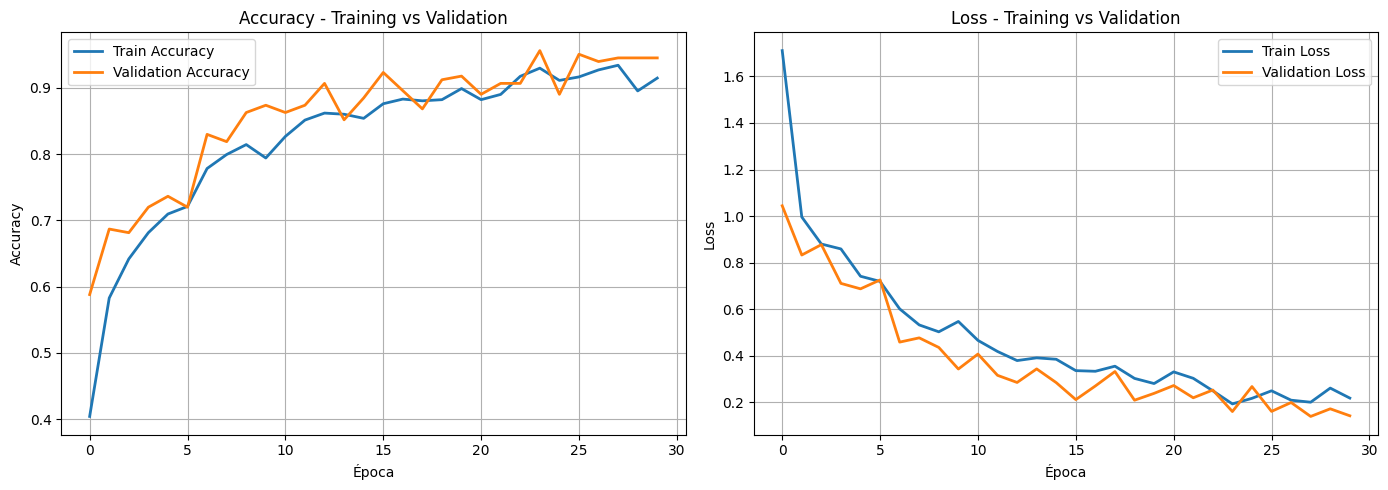

In [68]:
def plot_training_history(history):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfica de Accuracy
    ax1.plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
    ax1.set_title('Accuracy - Training vs Validation')
    ax1.set_xlabel('Época')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.grid(True)

    # Gráfica de Loss
    ax2.plot(history.history['loss'], label='Train Loss', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
    ax2.set_title('Loss - Training vs Validation')
    ax2.set_xlabel('Época')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.grid(True)

    plt.tight_layout()
    plt.show()

plot_training_history(trained_model)

## Evaluar el modelo

In [69]:
def evaluate_model(model, scaled_test_images, test_labels):
    test_loss, test_accuracy = model.evaluate(scaled_test_images, test_labels)
    return (test_loss, test_accuracy)

In [70]:
# Evaluamos usando el generador de test
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test loss: {test_loss}')
print(f'Test accuracy: {test_accuracy}')

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 85ms/step - accuracy: 0.9533 - loss: 0.1435
Test loss: 0.14349395036697388
Test accuracy: 0.9532967209815979


In [71]:
# Corregimos la evaluación para usar el generador
test_loss, test_accuracy = model.evaluate(test_generator)
print(f"Test loss: {test_loss}")
print(f"Test accuracy: {test_accuracy}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 49ms/step - accuracy: 0.9533 - loss: 0.1435
Test loss: 0.14349395036697388
Test accuracy: 0.9532967209815979


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step


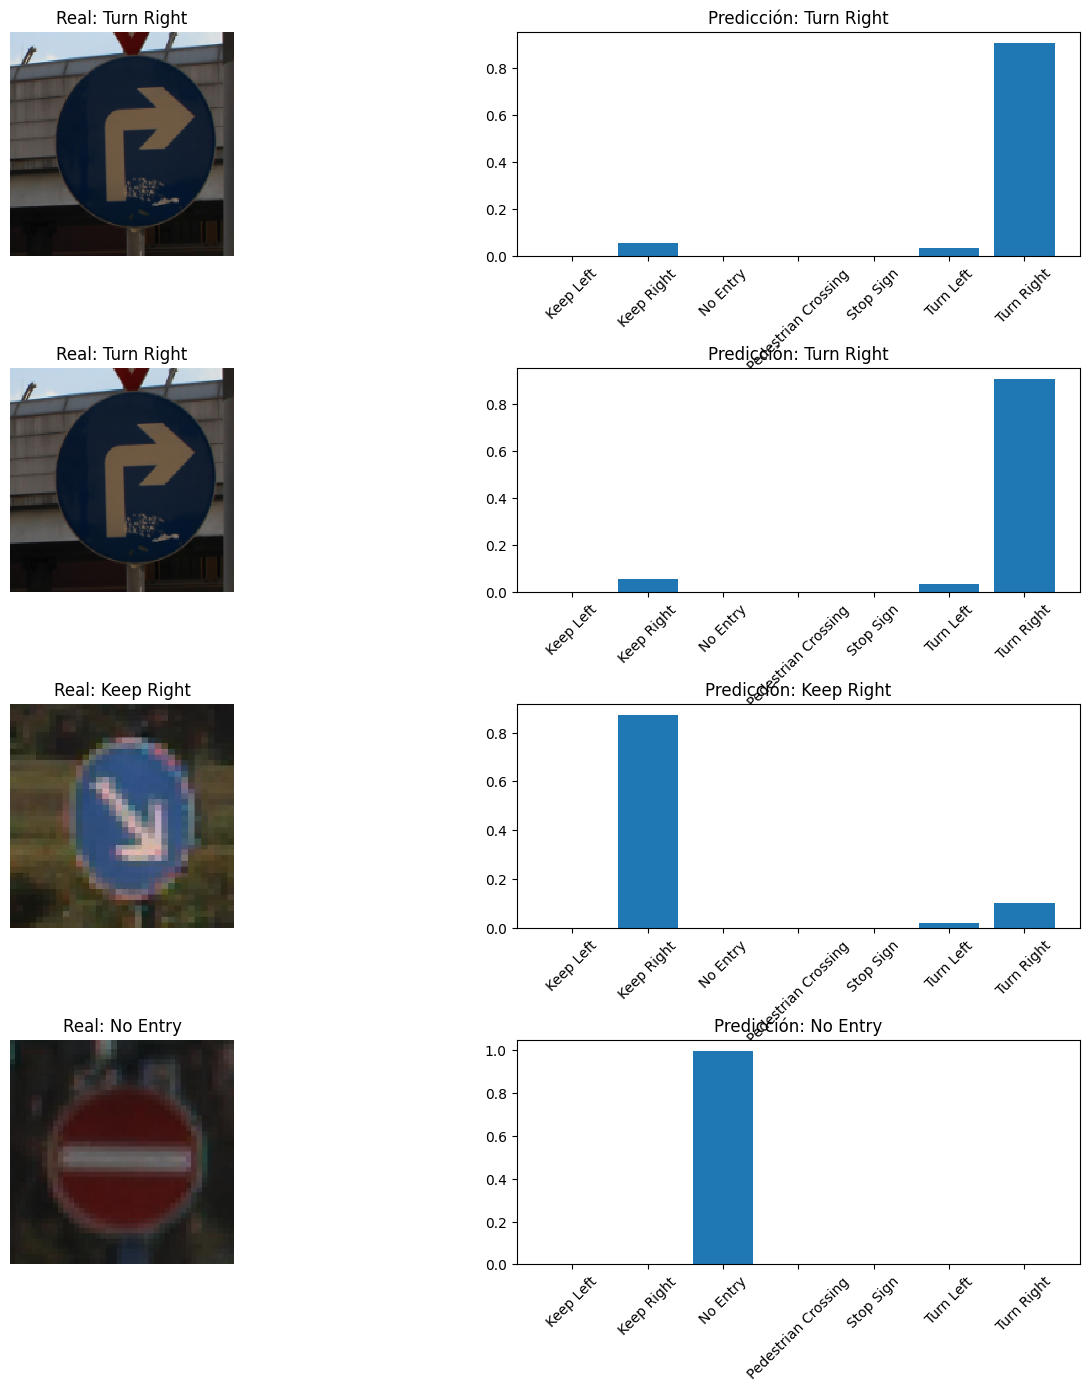

In [73]:
# Obtenemos un lote (batch) de imágenes y etiquetas del generador de prueba
test_images, test_labels_batch = next(test_generator)

# Seleccionamos 4 índices aleatorios del lote
random_inx = np.random.choice(test_images.shape[0], 4)
sample_images = test_images[random_inx]
sample_labels = test_labels_batch[random_inx]

# Realizamos la predicción
predictions = model.predict(sample_images)

# Mapeo de índices a nombres de clases
class_names = list(test_generator.class_indices.keys())

fig, axes = plt.subplots(4, 2, figsize=(16, 16))
fig.subplots_adjust(hspace=0.5, wspace=0.2)

for i, (prediction, image, label) in enumerate(zip(predictions, sample_images, sample_labels)):
    # Mostrar imagen
    axes[i, 0].imshow(image)
    axes[i, 0].axis('off')
    actual_cls = class_names[np.argmax(label)]
    axes[i, 0].set_title(f'Real: {actual_cls}')

    # Mostrar gráfico de barras de predicciones
    axes[i, 1].bar(class_names, prediction)
    axes[i, 1].set_xticks(range(len(class_names)))
    axes[i, 1].set_xticklabels(class_names, rotation=45)
    pred_cls = class_names[np.argmax(prediction)]
    axes[i, 1].set_title(f'Predicción: {pred_cls}')

plt.show()